### On each individual group


Kolmogorov-Smirnov Test Results for Salary Normality:
Gender           Occupation  Occupation_Code  Sample_Size  KS_Statistic      p_value  Normality
  Male   Software Developer                1          300      0.454700 3.432187e-57 Non-Normal
  Male              Teacher                2          300      0.230559 1.673781e-14 Non-Normal
  Male                Nurse                3          300      0.412407 1.109094e-46 Non-Normal
  Male       Police Officer                4          300      0.372840 6.080039e-38 Non-Normal
  Male Marketing Consultant                5          300      0.295870 9.002891e-24 Non-Normal
Female   Software Developer                1          300      0.404430 7.756534e-45 Non-Normal
Female              Teacher                2          300      0.246641 1.470682e-16 Non-Normal
Female                Nurse                3          300      0.403117 1.546116e-44 Non-Normal
Female       Police Officer                4          300      0.306037 1.943118e-

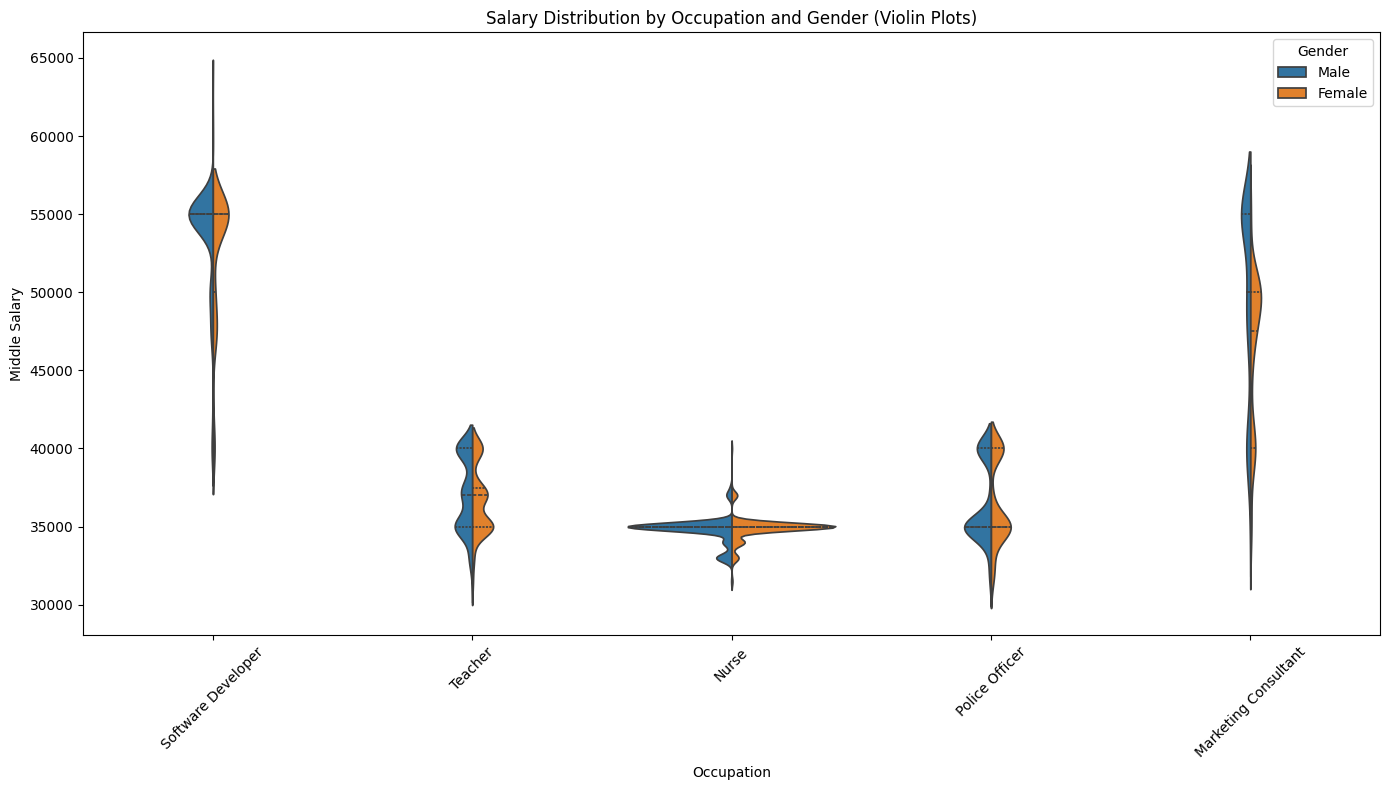

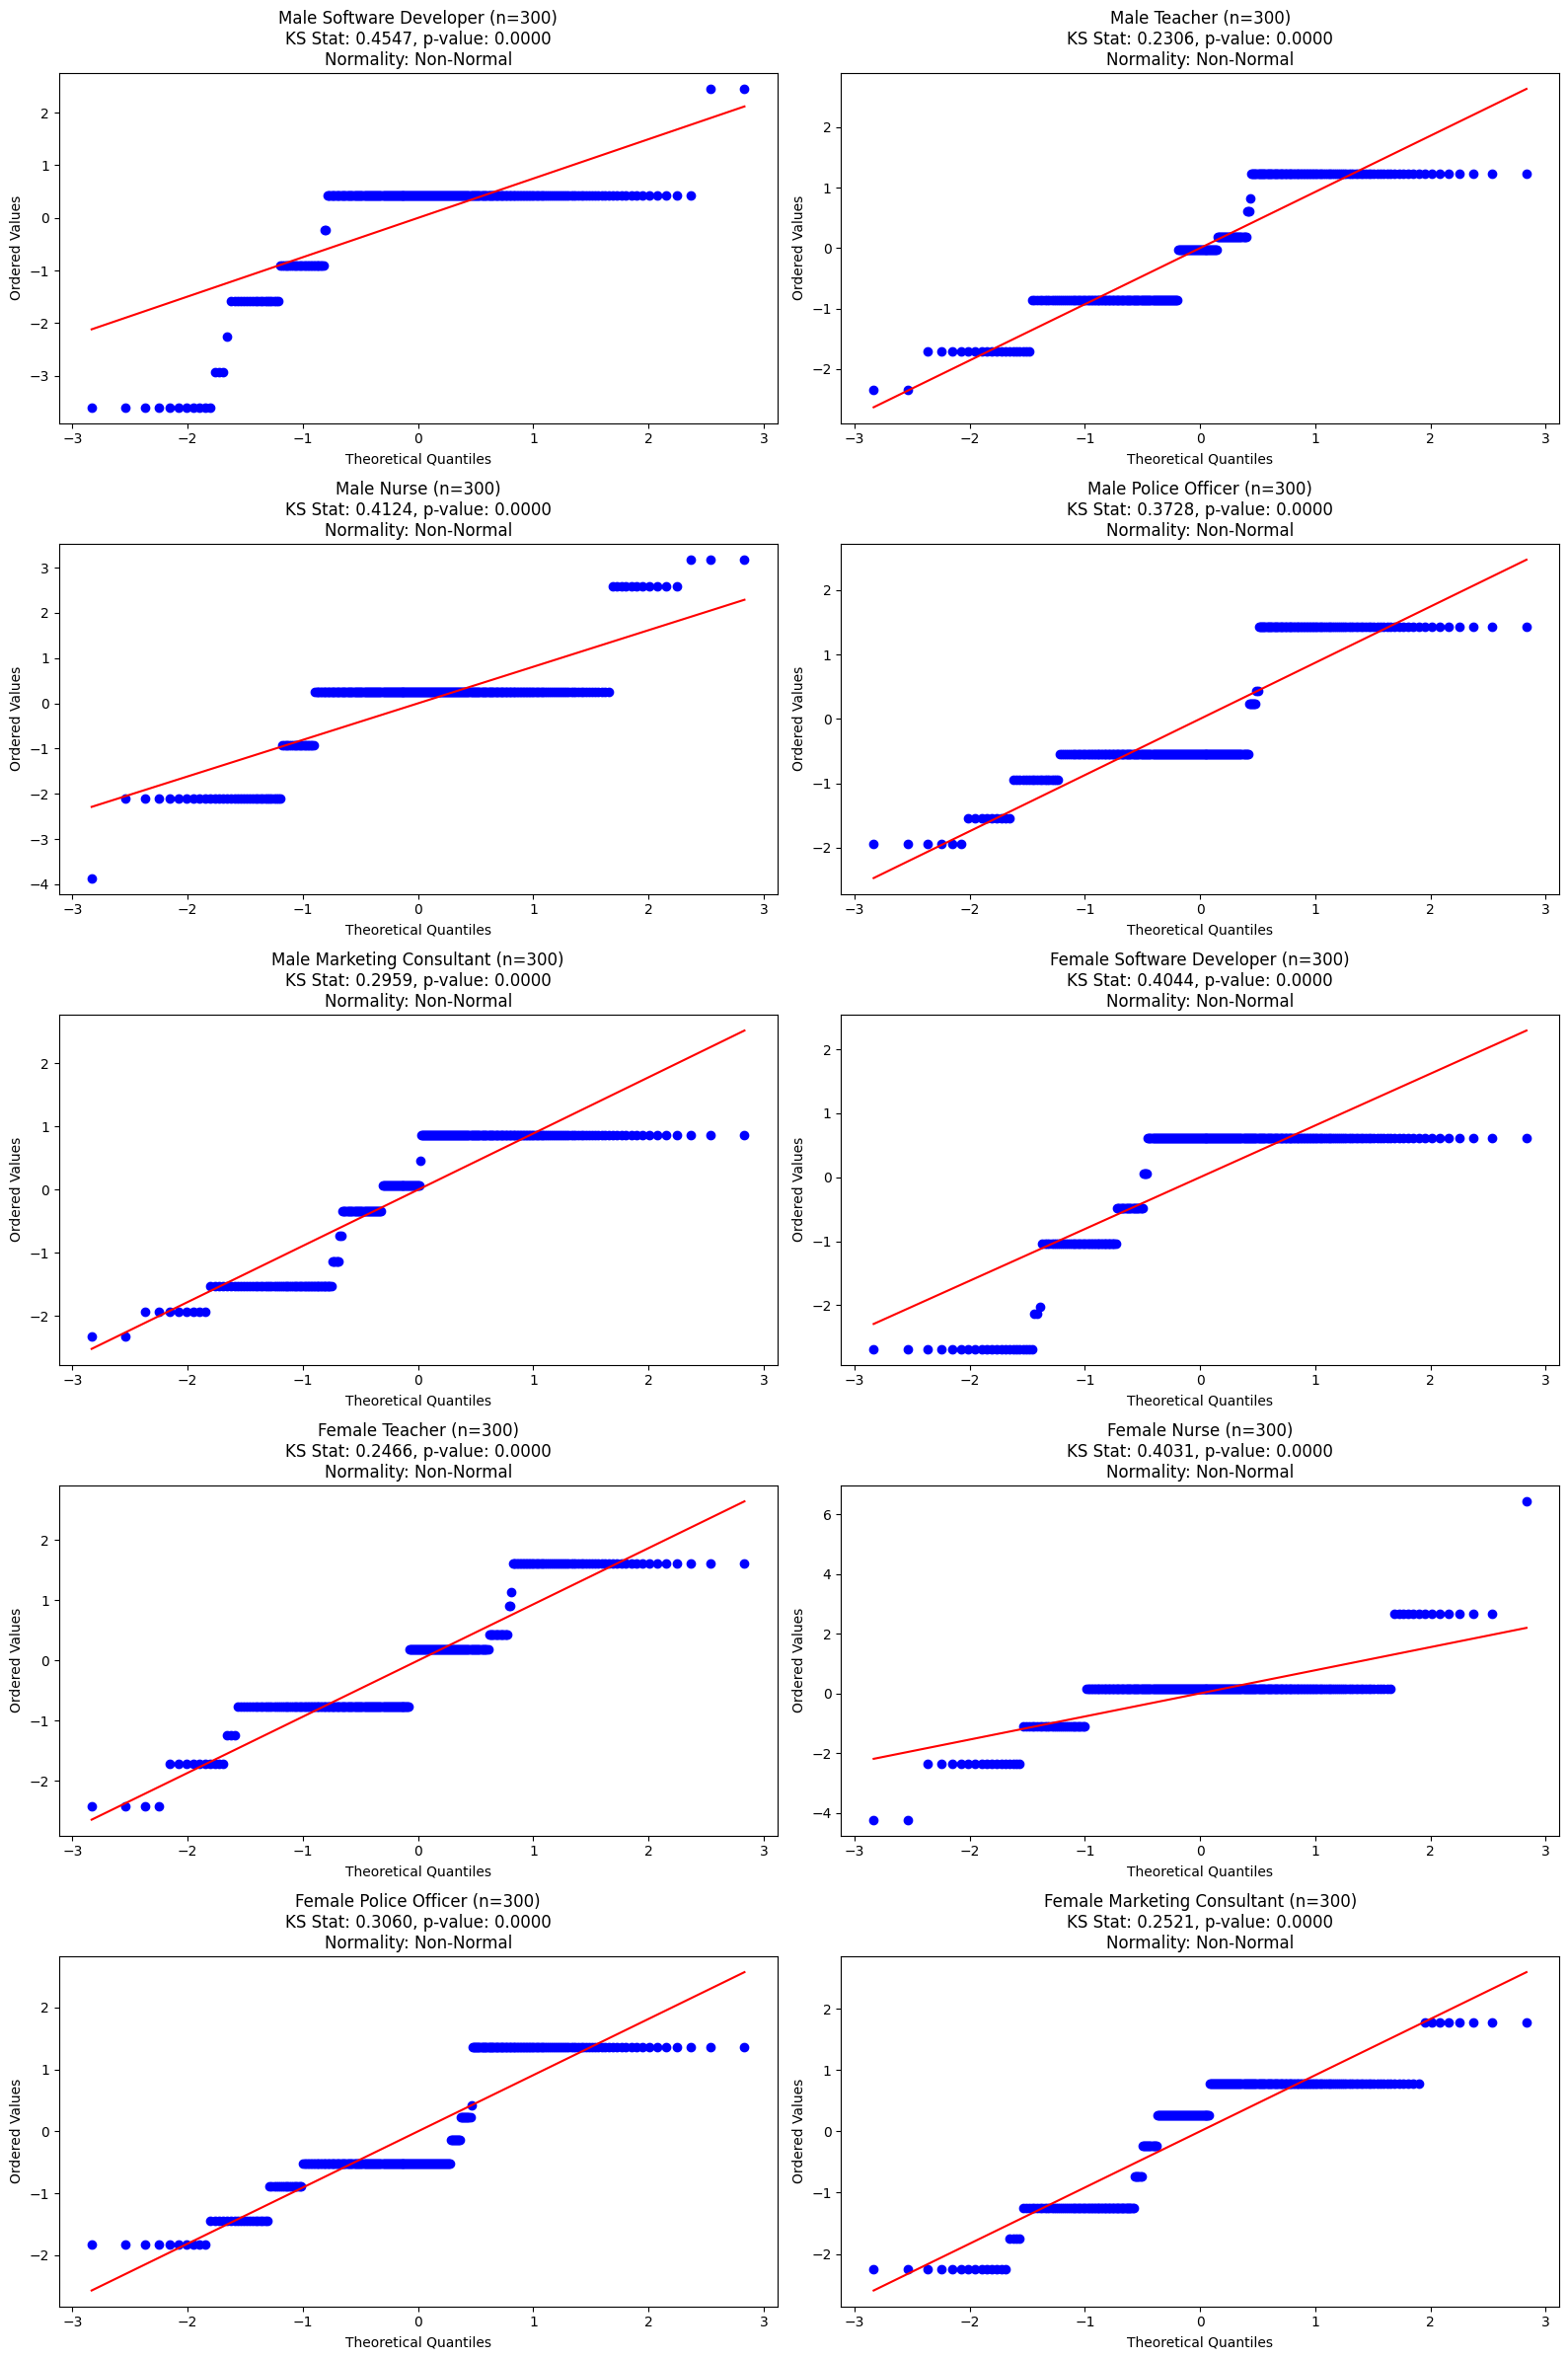

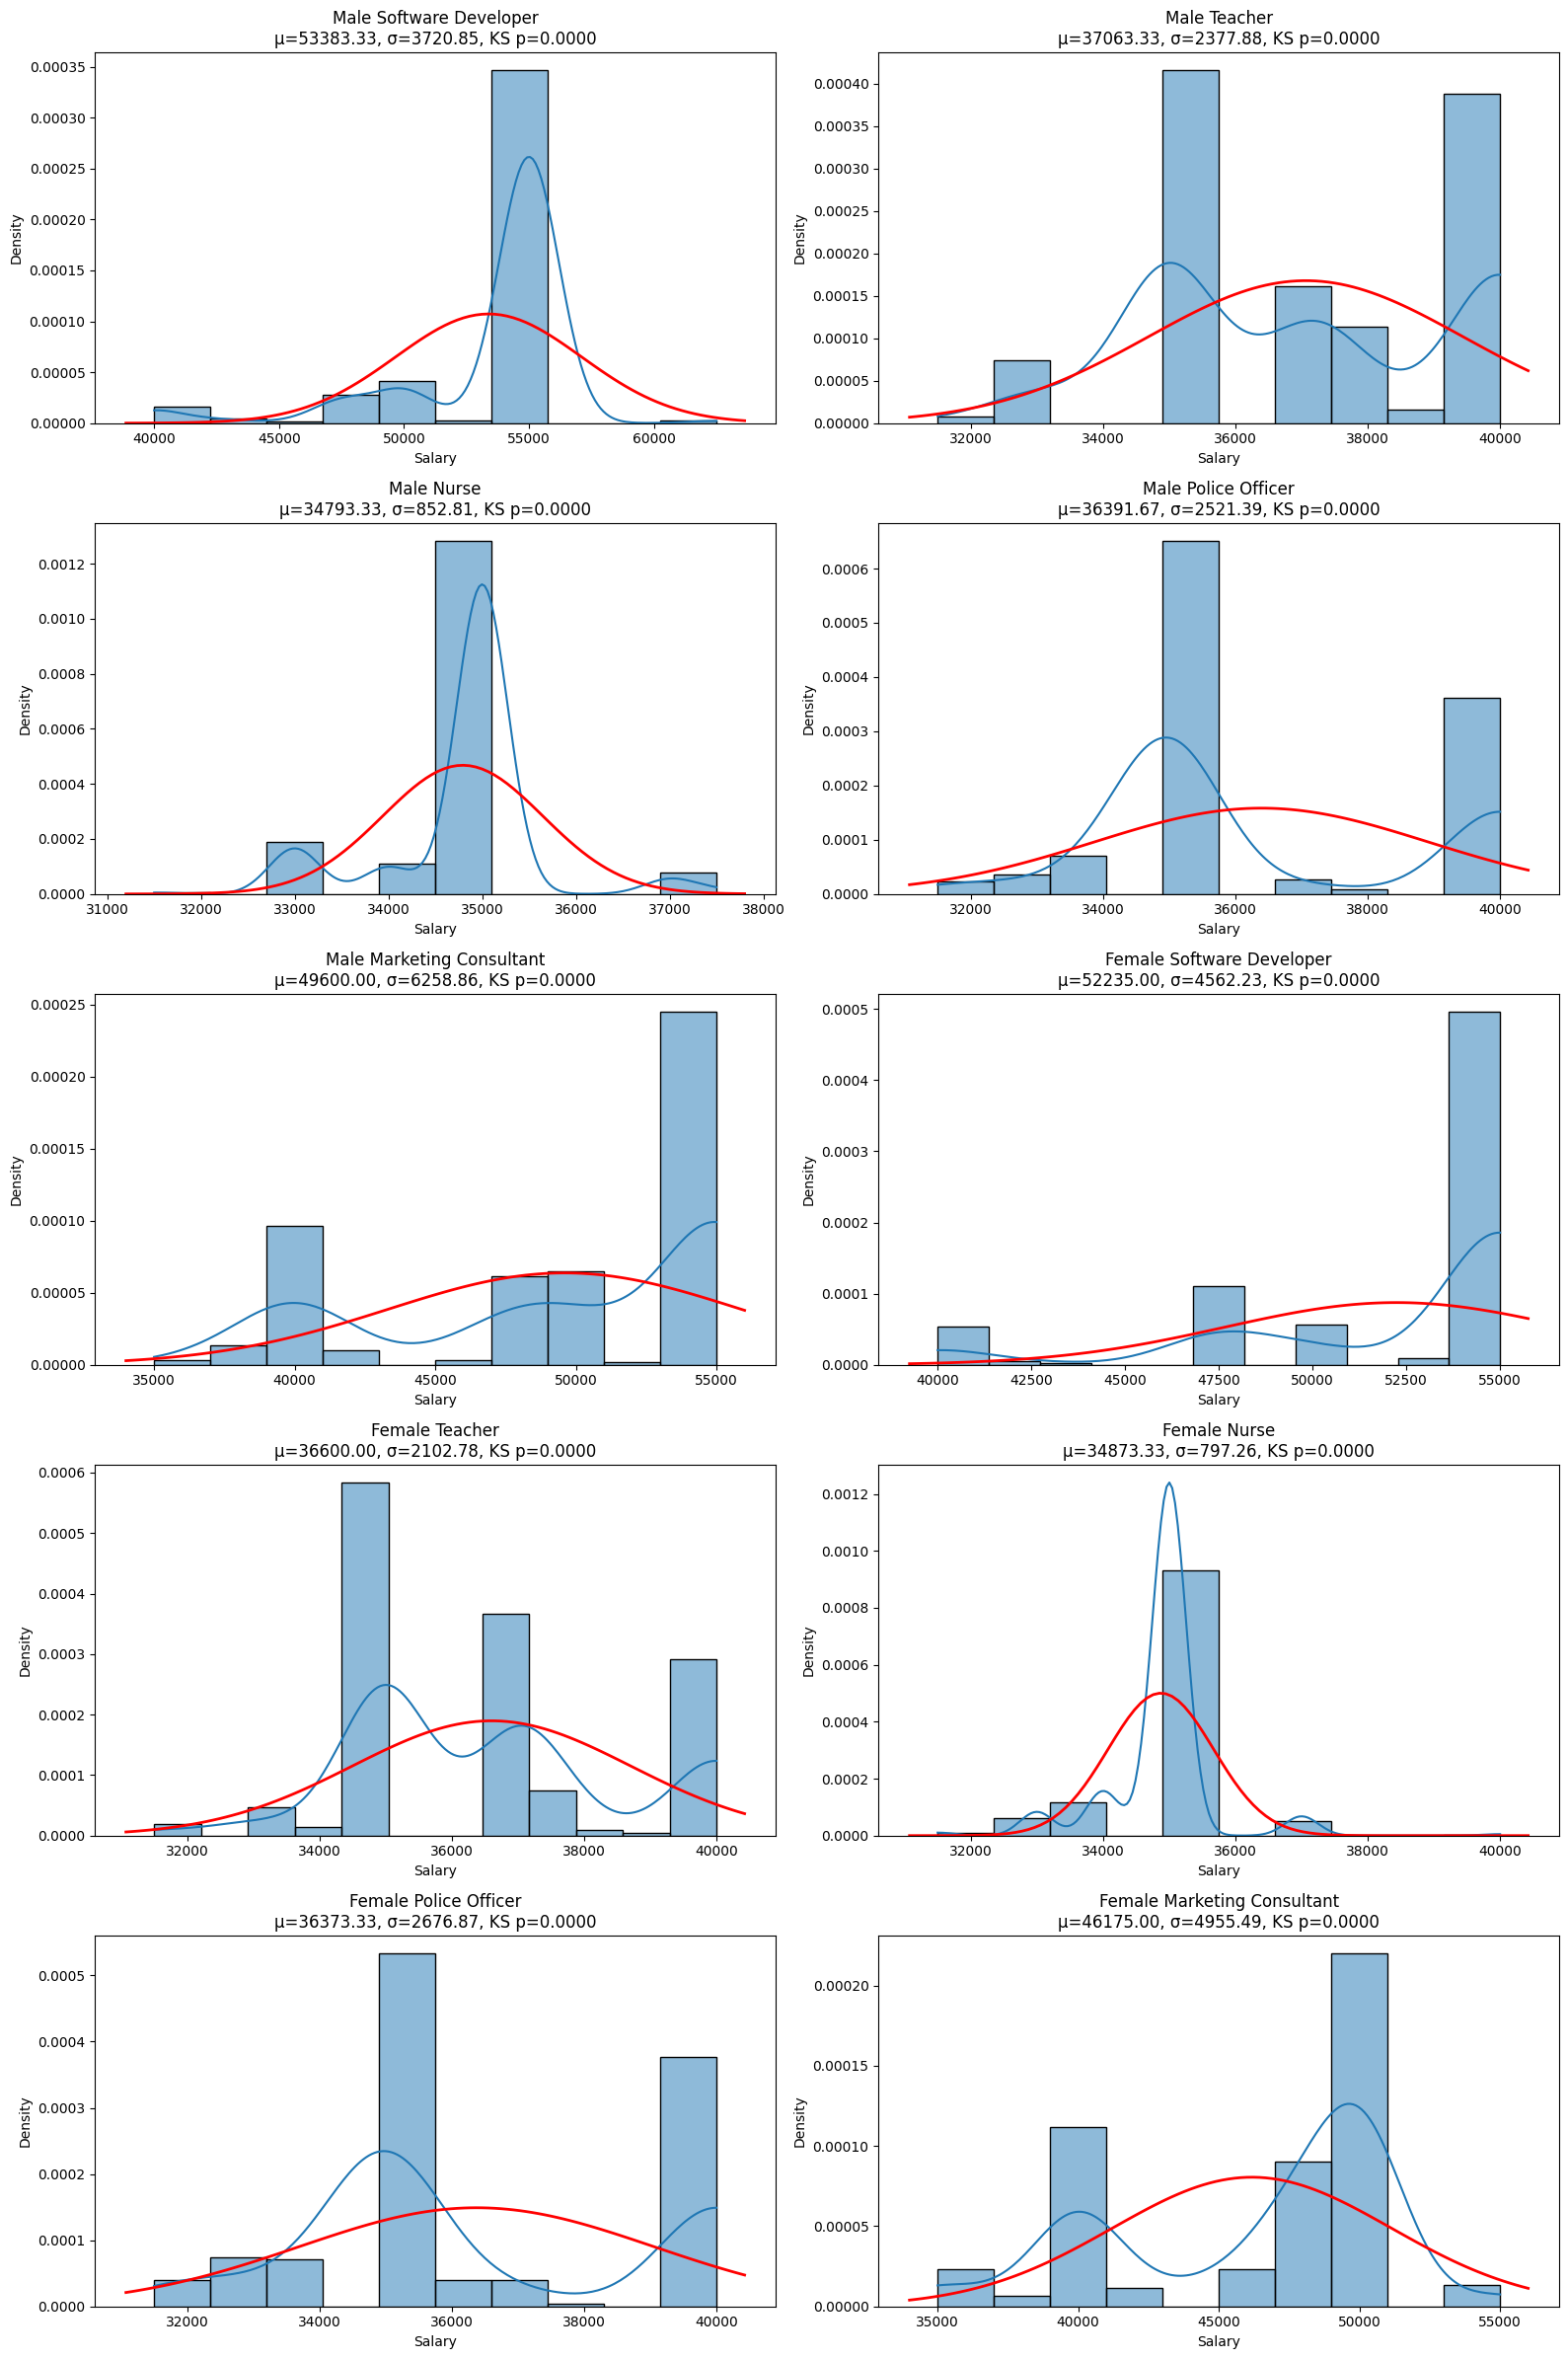

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load your dataset (replace 'salaries.csv' with your actual file path)
df = pd.read_csv('salaries_3000.csv')

# Map occupation codes to meaningful names (optional but recommended)
occupation_map = {
    1: 'Software Developer',
    2: 'Teacher',
    3: 'Nurse',
    4: 'Police Officer',
    5: 'Marketing Consultant',
}
df['occupation_name'] = df['occupation'].map(occupation_map)

# Map gender codes to full names
gender_map = {'M': 'Male', 'F': 'Female'}
df['gender_name'] = df['gender'].map(gender_map)

# Kolmogorov-Smirnov Test for Normality
results = []

for gender in ['Male', 'Female']:
    for occ_code, occ_name in occupation_map.items():
        group = df[(df['gender_name'] == gender) & (df['occupation'] == occ_code)]
        salaries = group['middle_salary'].values
        
        if len(salaries) < 2:
            print(f"Warning: Insufficient data for {gender} {occ_name}")
            continue
            
        # Standardize data (μ=0, σ=1)
        standardized = (salaries - np.mean(salaries)) / np.std(salaries)
        
        # Perform K-S test against standard normal distribution
        ks_stat, p_value = stats.kstest(standardized, 'norm')
        
        results.append({
            'Gender': gender,
            'Occupation': occ_name,
            'Occupation_Code': occ_code,
            'Sample_Size': len(salaries),
            'KS_Statistic': ks_stat,
            'p_value': p_value,
            'Normality': 'Normal' if p_value > 0.05 else 'Non-Normal'
        })

results_df = pd.DataFrame(results)

# Display results
print("="*80)
print("Kolmogorov-Smirnov Test Results for Salary Normality:")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)
print(f"Normal Groups: {sum(results_df['Normality'] == 'Normal')}/{len(results_df)}")
print(f"Non-Normal Groups: {sum(results_df['Normality'] == 'Non-Normal')}/{len(results_df)}")
print("="*80)

# **VIOLIN PLOTS (instead of boxplots)**
plt.figure(figsize=(14, 8))
sns.violinplot(
    x='occupation_name', 
    y='middle_salary', 
    hue='gender_name', 
    data=df,
    split=True,  # Split violins for gender comparison
    inner='quartile'  # Show quartile lines inside violins
)
plt.title('Salary Distribution by Occupation and Gender (Violin Plots)')
plt.xlabel('Occupation')
plt.ylabel('Middle Salary')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('salary_violin_plots.png', dpi=300)
plt.show()

# Q-Q Plots for visual validation
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, row in enumerate(results_df.itertuples()):
    group = df[
        (df['gender_name'] == row.Gender) & 
        (df['occupation'] == row.Occupation_Code)
    ]
    salaries = group['middle_salary'].values
    standardized = (salaries - np.mean(salaries)) / np.std(salaries)
    
    stats.probplot(standardized, dist="norm", plot=axes[i])
    axes[i].set_title(
        f"{row.Gender} {row.Occupation} (n={row.Sample_Size})\n"
        f"KS Stat: {row.KS_Statistic:.4f}, p-value: {row.p_value:.4f}\n"
        f"Normality: {row.Normality}"
    )
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Ordered Values')

plt.tight_layout()
plt.savefig('normality_qq_plots.png', dpi=300)
plt.show()

# Histograms with normal distribution overlay
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, row in enumerate(results_df.itertuples()):
    group = df[
        (df['gender_name'] == row.Gender) & 
        (df['occupation'] == row.Occupation_Code)
    ]
    salaries = group['middle_salary'].values
    
    # Create histogram
    sns.histplot(salaries, kde=True, stat='density', ax=axes[i])
    
    # Overlay normal distribution
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    mean = np.mean(salaries)
    std = np.std(salaries)
    p = stats.norm.pdf(x, mean, std)
    axes[i].plot(x, p, 'r', linewidth=2)
    
    axes[i].set_title(
        f"{row.Gender} {row.Occupation}\n"
        f"μ={mean:.2f}, σ={std:.2f}, KS p={row.p_value:.4f}"
    )
    axes[i].set_xlabel('Salary')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.savefig('normality_histograms.png', dpi=300)
plt.show()

### On the whole dataset and M/F

Normality Test Results:
             Dataset  Sample_Size  KS_Statistic    KS_p_value  Shapiro_Statistic  Shapiro_p_value Normality_KS Normality_Shapiro
   All Data (n=3000)         3000      0.247758 1.073379e-162           0.800382     1.563718e-51   Non-Normal        Non-Normal
  Male Only (n=1500)         1500      0.256981  7.723236e-88           0.782424     9.453419e-41   Non-Normal        Non-Normal
Female Only (n=1500)         1500      0.236747  1.900669e-74           0.815384     2.200190e-38   Non-Normal        Non-Normal

Interpretation Guide:
- KS p-value > 0.05: Normal distribution (Kolmogorov-Smirnov)
- Shapiro p-value > 0.05: Normal distribution (Shapiro-Wilk)


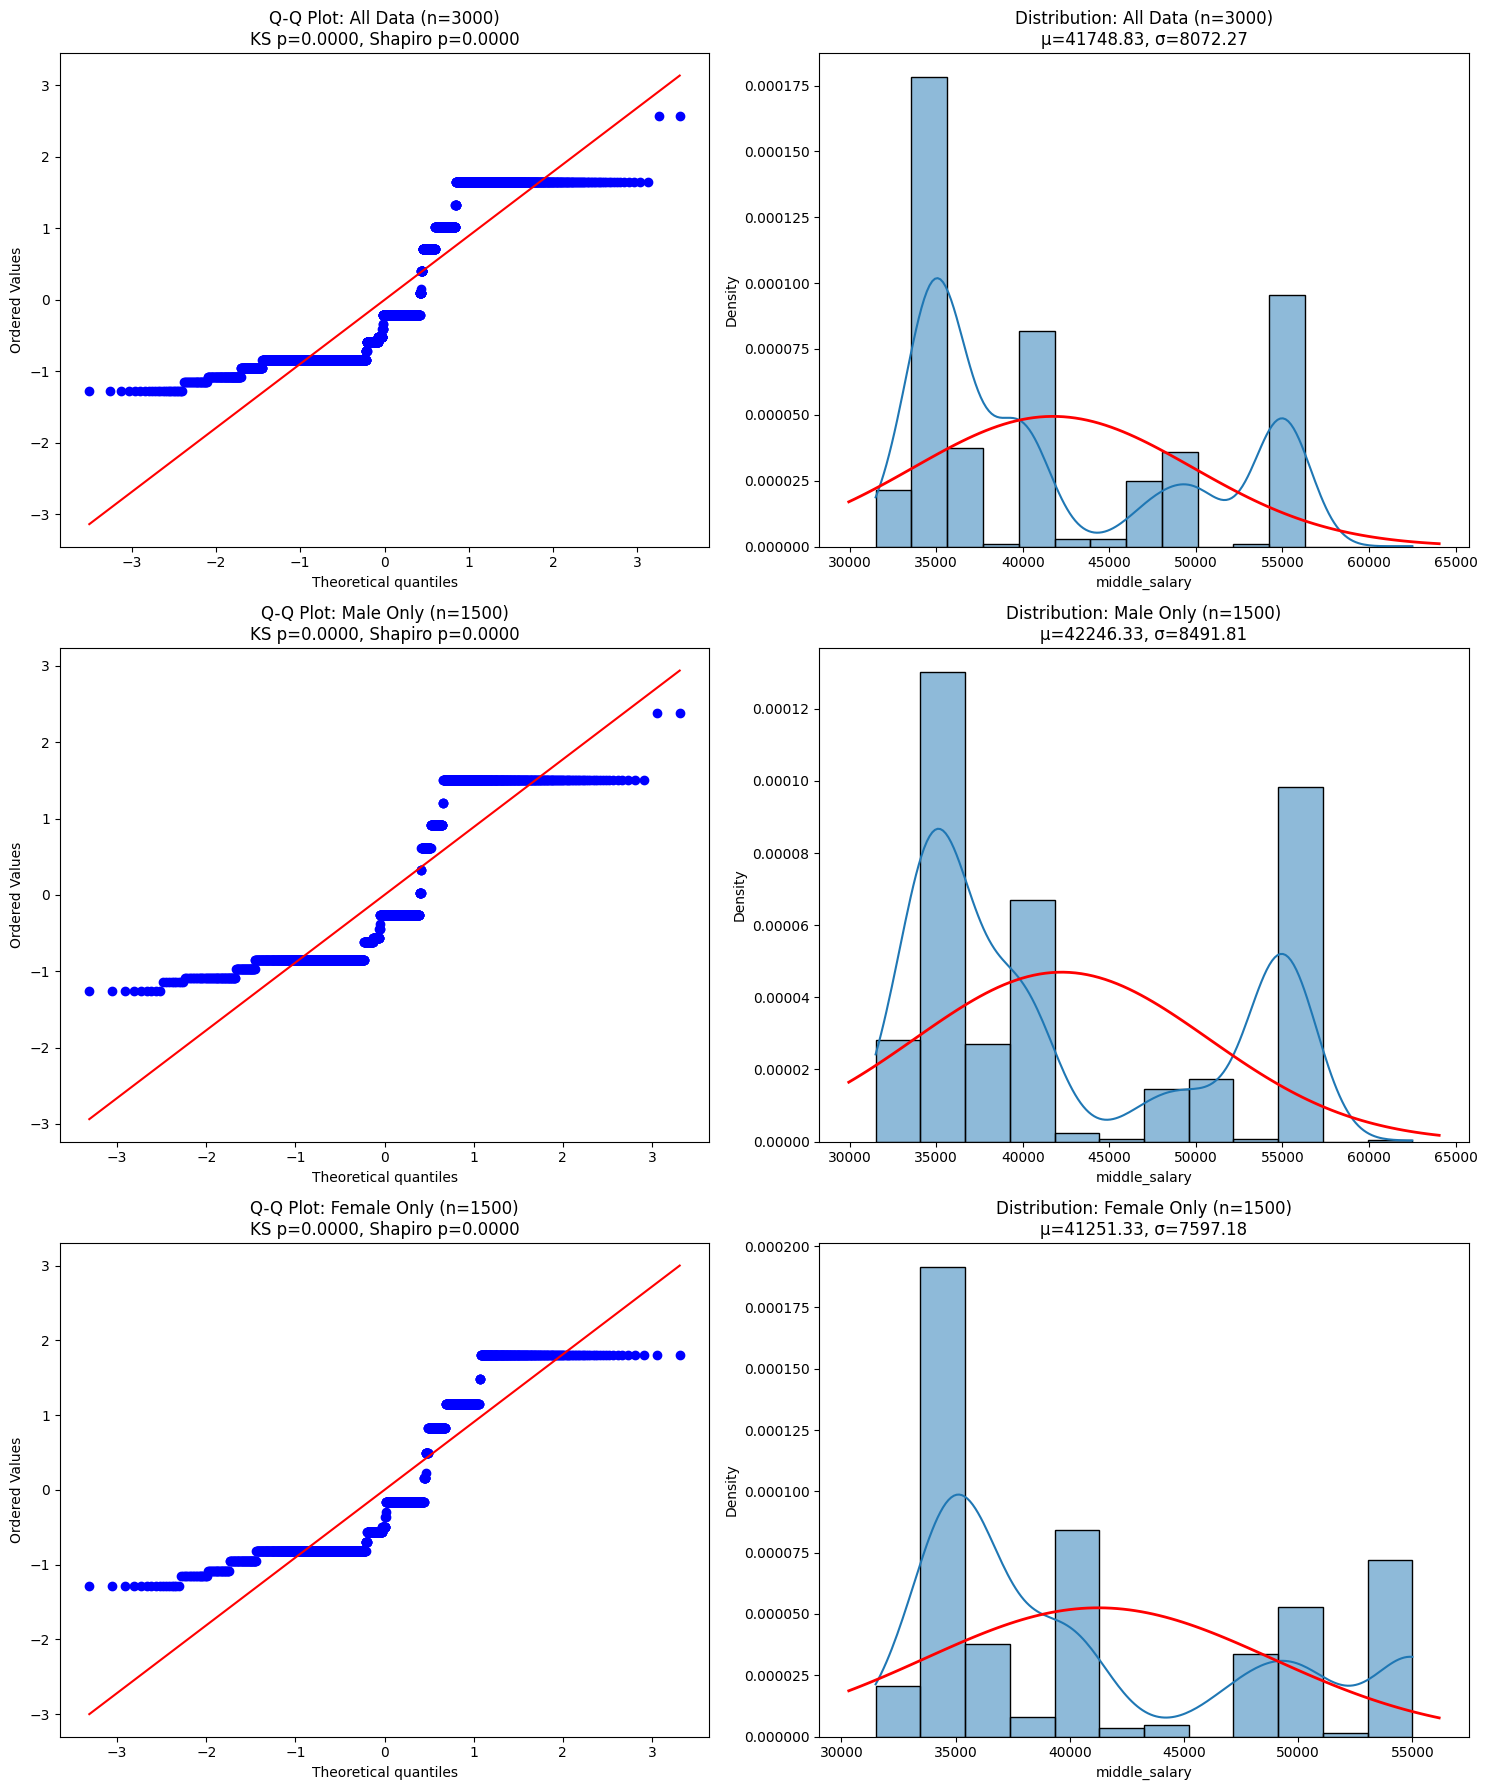

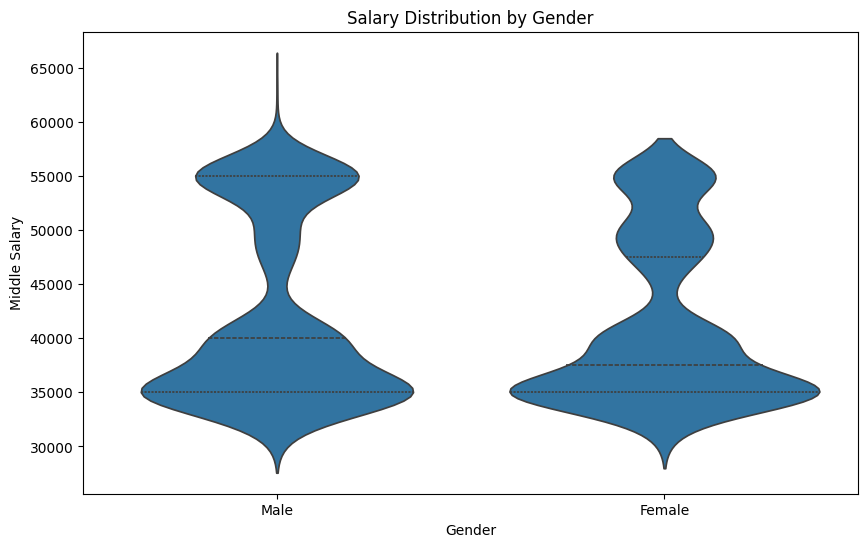

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load your dataset
df = pd.read_csv('salaries_3000.csv')

# Define gender mapping
gender_map = {'M': 'Male', 'F': 'Female'}
df['gender_name'] = df['gender'].map(gender_map)

# Function to perform normality tests and generate plots
def normality_test(data, name, ax1, ax2):
    # Standardize data
    standardized = (data - np.mean(data)) / np.std(data)
    
    # Perform both KS and Shapiro-Wilk tests
    ks_stat, ks_p = stats.kstest(standardized, 'norm')
    shapiro_stat, shapiro_p = stats.shapiro(data)
    
    # Q-Q Plot
    stats.probplot(standardized, dist="norm", plot=ax1)
    ax1.set_title(f'Q-Q Plot: {name}\nKS p={ks_p:.4f}, Shapiro p={shapiro_p:.4f}')
    
    # Histogram with normal overlay
    sns.histplot(data, kde=True, stat='density', ax=ax2)
    xmin, xmax = ax2.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(data), np.std(data))
    ax2.plot(x, p, 'r', linewidth=2)
    ax2.set_title(f'Distribution: {name}\nμ={np.mean(data):.2f}, σ={np.std(data):.2f}')
    
    return {
        'Dataset': name,
        'Sample_Size': len(data),
        'KS_Statistic': ks_stat,
        'KS_p_value': ks_p,
        'Shapiro_Statistic': shapiro_stat,
        'Shapiro_p_value': shapiro_p,
        'Normality_KS': 'Normal' if ks_p > 0.05 else 'Non-Normal',
        'Normality_Shapiro': 'Normal' if shapiro_p > 0.05 else 'Non-Normal'
    }

# Create figure for visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
results = []

# Test 1: Full dataset (3000 points)
results.append(normality_test(
    df['middle_salary'], 
    'All Data (n=3000)', 
    axes[0,0], axes[0,1]
))

# Test 2: Male subset (1500 points)
male_data = df[df['gender'] == 'M']['middle_salary']
results.append(normality_test(
    male_data, 
    'Male Only (n=1500)', 
    axes[1,0], axes[1,1]
))

# Test 3: Female subset (1500 points)
female_data = df[df['gender'] == 'F']['middle_salary']
results.append(normality_test(
    female_data, 
    'Female Only (n=1500)', 
    axes[2,0], axes[2,1]
))

# Display results
results_df = pd.DataFrame(results)
print("="*80)
print("Normality Test Results:")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80)
print("Interpretation Guide:")
print("- KS p-value > 0.05: Normal distribution (Kolmogorov-Smirnov)")
print("- Shapiro p-value > 0.05: Normal distribution (Shapiro-Wilk)")
print("="*80)

plt.tight_layout()
plt.savefig('normality_tests.png', dpi=300)
plt.show()

# Additional: Violin plot comparison
plt.figure(figsize=(10, 6))
sns.violinplot(x='gender_name', y='middle_salary', data=df, inner='quartile')
plt.title('Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Middle Salary')
plt.savefig('gender_violin_plot.png', dpi=300)
plt.show()